# 第 27 课：ONNX Runtime INT8——量化、模型大小与 Benchmark

本课对第 25 课模型进行动态 INT8 量化，并比较输出误差、文件大小和 CPU 延迟。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 量化与部署 |
| 建议投入 | 3～5 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 26 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | 动态 INT8、精度回归、目标硬件 benchmark |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：动态 INT8、精度回归、目标硬件 benchmark。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


In [1]:
from pathlib import Path
import time
import sys
import numpy as np
import matplotlib.pyplot as plt

def find_root():
    here=Path.cwd().resolve()
    for p in [here,*here.parents]:
        if (p/"pyproject.toml").exists(): return p
    raise FileNotFoundError("请从 learn_asr 或 notebooks 目录启动 Jupyter")

ROOT=find_root(); ARTIFACTS=ROOT/"artifacts";ARTIFACTS.mkdir(exist_ok=True)
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
plt.rcParams["figure.figsize"]=(11,4)
print("项目根目录:",ROOT)

import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic,QuantType
from deployment.model import FEATURE_DIM,CHUNK_FRAMES,CACHE_FRAMES,export_onnx

项目根目录: G:\learn_asr


## 1. 生成 FP32 与 INT8 模型

In [2]:
fp32=ARTIFACTS/"streaming_ctc_demo.onnx"
if not fp32.exists(): export_onnx(fp32)
int8=ARTIFACTS/"streaming_ctc_demo.int8.onnx"
quantize_dynamic(str(fp32),str(int8),weight_type=QuantType.QInt8)
print("FP32 KB",fp32.stat().st_size/1024,"INT8 KB",int8.stat().st_size/1024,
      "ratio",int8.stat().st_size/fp32.stat().st_size)

FP32 KB 7.9658203125 INT8 KB 10.34375 ratio 1.2985166114993256


## 2. 不能只看文件大小：先比较输出

In [3]:
sess32=ort.InferenceSession(str(fp32),providers=["CPUExecutionProvider"])
sess8=ort.InferenceSession(str(int8),providers=["CPUExecutionProvider"])
rng=np.random.default_rng(10);errors=[];agreements=[]
for _ in range(100):
    x=rng.normal(size=(1,CHUNK_FRAMES,FEATURE_DIM)).astype(np.float32)
    c=rng.normal(size=(1,CACHE_FRAMES,FEATURE_DIM)).astype(np.float32)
    y32=sess32.run(None,{"frames":x,"cache":c})[0];y8=sess8.run(None,{"frames":x,"cache":c})[0]
    errors.append(np.max(np.abs(y32-y8)));agreements.append(np.mean(y32.argmax(-1)==y8.argmax(-1)))
print("max abs error: median/max",np.median(errors),np.max(errors))
print("frame argmax agreement",np.mean(agreements))

max abs error: median/max

 0.005740024 0.009383142
frame argmax agreement 0.99


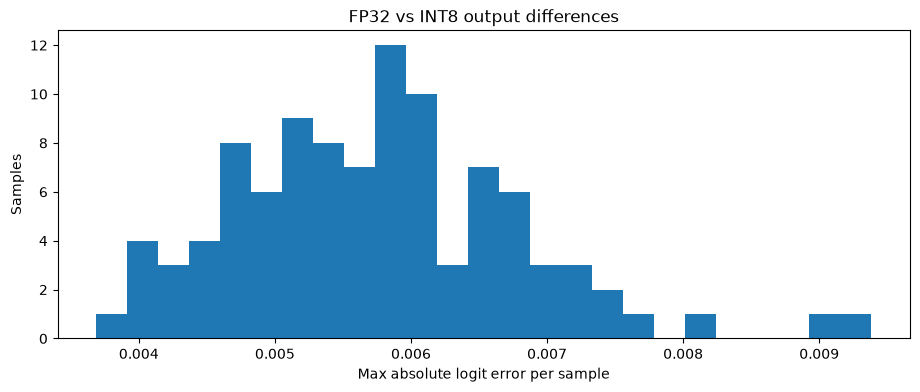

In [4]:
plt.hist(errors,bins=25);plt.xlabel("Max absolute logit error per sample");plt.ylabel("Samples")
plt.title("FP32 vs INT8 output differences");plt.show()

## 3. 正确 benchmark：warm-up、重复、分位数

In [5]:
x=rng.normal(size=(1,CHUNK_FRAMES,FEATURE_DIM)).astype(np.float32);c=np.zeros((1,CACHE_FRAMES,FEATURE_DIM),np.float32)
def bench(session,n=1000):
    for _ in range(50):session.run(None,{"frames":x,"cache":c})
    times=[]
    for _ in range(n):
        t=time.perf_counter();session.run(None,{"frames":x,"cache":c});times.append((time.perf_counter()-t)*1000)
    return np.asarray(times)
t32=bench(sess32);t8=bench(sess8)
for name,times in [("FP32",t32),("INT8",t8)]:print(name,"P50/P90/P99 ms",*[np.percentile(times,p) for p in [50,90,99]])
print("median speedup",np.median(t32)/np.median(t8))

FP32 P50/P90/P99 ms 0.04249999619787559 0.04400000034365803 0.058006997860502445
INT8 P50/P90/P99 ms 0.059600002714432776 0.06393999938154594 0.14196399635693518
median speedup 0.7130871520511485


小模型可能量化后没有明显加速，甚至变慢，因为量化开销、算子规模和硬件 kernel 会主导结果。这不是实验失败，而是重要结论：**必须在目标硬件上测量。**

## 4. ASR 精度验收层次

1. 张量误差；
2. frame argmax agreement；
3. Greedy 文本 agreement；
4. Beam + LM 文本 agreement；
5. 全测试集 CER/WER；
6. 噪声、长音频、重复字符、热词等分桶回归。

## 本课测试

1. dynamic quantization 的 activation scale 何时计算？
2. INT8 文件更小是否保证 RTF 更低？
3. 为什么 frame argmax agreement 比 logit MSE更接近 CTC 行为？
4. 量化模型为什么仍需独立 CER/WER 测试？
5. benchmark 为什么要固定线程、硬件和输入 shape？

<details><summary>展开参考答案</summary>

1. 运行时。2. 不保证。3. CTC 解码依赖类别排序，但最终仍需文本评估。4. 小 logit 误差可能改变 beam 排名和文本。5. 否则结果不可复现和公平比较。

</details>

<!-- course-upgrade-v2 -->
## 强化练习：第 27 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `动态 INT8`、`精度回归`、`目标硬件 benchmark`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**INT8 文件更小但运行更慢**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**比较大小、logit、argmax、P50/P99 和 RTF**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**为服务选择 FP32/INT8 artifact**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：动态 INT8、精度回归、目标硬件 benchmark。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 动态 INT8、精度回归、目标硬件 benchmark。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
